# M1 — Якість даних 🧹

Проєкт **«4331 година»** — клімат квартири та відключення світла, Харків.
Дані реальні: власна система Home Assistant + погода Open-Meteo.

Це перший модуль. Тут ми не аналізуємо клімат — тут ми з'ясовуємо,
**наскільки даним взагалі можна вірити** і що з ними зробити перед аналізом.

## Питання

> **Наскільки дані брудні і що з ними треба зробити перед аналізом?**

Підпитання:
1. Скільки реальних годин вимірів у нас є на кожен датчик (покриття)?
2. Де дірки — і чи це поломка даних, чи факт із життя?
3. Чи є «застряглі» датчики, дублікати, викиди, нечислові стани?
4. Чи не зламає нам аналіз перехід на літній час?

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from src import cleaning

ROOT = pathlib.Path.cwd().parent
IMAGES = ROOT / "images"

sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 110, "font.size": 12,
                     "axes.titlesize": 14, "axes.labelsize": 12})
pd.set_option("display.width", 200)

out = cleaning.run_all(ROOT)          # усе чищення живе у src/cleaning.py
stats, history, weather = cleaning.load_raw(ROOT)
hourly, detailed = out["hourly"], out["detailed"]
wide, gaps, report, totals = out["wide"], out["gaps"], out["report"], out["totals"]
print("готово")

готово


## Дані

Два джерела всередині Home Assistant — і це не примха, а обмеження системи.

| Джерело | Детальність | Глибина | Навіщо |
|---|---|---|---|
| `history` (REST) | кожні ~14 секунд | **10 днів** | короткі відключення (секунди-хвилини), детекція подій |
| `statistics` (WebSocket) | 1 година: mean / min / max | **з 16.03.2026** | уся картина за 6 місяців |

Home Assistant тримає детальну історію лише 10 днів (`purge_keep_days`),
далі стискає її в погодинні середні. Підіймати цей строк ніхто не буде — працюємо з тим, що є.
Тому: **довгі тренди рахуємо по погодинних даних, короткі події — по детальних.**

Третє джерело — погода Open-Meteo (Харків, погодинно, UTC).

In [2]:
src_tbl = pd.DataFrame([
    {"джерело": "stats_hourly.csv (statistics)", "рядків": len(stats),
     "датчиків": stats.entity_id.nunique(),
     "від": str(stats.ts.min())[:16], "до": str(stats.ts.max())[:16]},
    {"джерело": "history_10d.csv (history)", "рядків": len(history),
     "датчиків": history.entity_id.nunique(),
     "від": str(history.ts.min())[:16], "до": str(history.ts.max())[:16]},
    {"джерело": "weather.csv (Open-Meteo)", "рядків": len(weather), "датчиків": 1,
     "від": str(weather.ts.min())[:16], "до": str(weather.ts.max())[:16]},
])
src_tbl

,джерело,рядків,датчиків,від,до
0,stats_hourly.csv (statistics),43940,14,2026-03-16 08:00,2026-09-15 17:00
1,history_10d.csv (history),365129,8,2026-09-05 18:27,2026-09-15 18:27
2,weather.csv (Open-Meteo),4416,1,2026-03-16 00:00,2026-09-15 23:00


## Вісім перевірок

Нижче — вісім типових проблем сенсорних даних. По кожній: скільки знайшли і що зробили.

### 1. Нечислові стани: `unknown` / `unavailable`

Датчик іноді пише не число, а слово. Такий рядок не можна кинути в `mean()` —
його треба прибрати й **порахувати**, бо це сам по собі сигнал.

In [3]:
nn = history[pd.to_numeric(history.state, errors="coerce").isna()]
print(f"нечислових станів: {len(nn)} з {len(history):,} рядків "
      f"({len(nn)/len(history)*100:.3f} %)")
display(nn.state.value_counts().rename("скільки").to_frame())
display(nn.groupby("entity_id").size().rename("скільки").to_frame()
          .assign(датчик=lambda d: d.index.map(cleaning.LABELS_UA)))

нечислових станів: 82 з 365,129 рядків (0.022 %)


,скільки
state,
unavailable,78
unknown,4


,скільки,датчик
entity_id,,
sensor.test_product_humidity,4,кімната · вологість
sensor.test_product_humidity_3,2,кладова · вологість
sensor.test_product_temperature,4,кімната · температура
sensor.test_product_temperature_3,2,кладова · температура
sensor.tiny_soil_sensor_temperature,70,квітка · температура (батарейка)


**Знайшли 82 рядки (0,02 %).** З них 70 — датчик квітки на батарейці:
він єдиний живиться не від розетки, тому «моргає» окремо від решти.
Решта 12 розкидані по чотирьох кімнатних датчиках. Усі прибрані.

### 2. Дублікати часу

Один датчик, одна година — один рядок. Якщо їх два, `groupby` тихо подвоїть вагу години.
Правило: лишаємо **останній** запис.

In [4]:
print("дублікатів (ts, entity_id) у погодинних:", stats.duplicated(["ts", "entity_id"]).sum())
print("дублікатів (ts, entity_id) у детальних: ", history.duplicated(["ts", "entity_id"]).sum())

дублікатів (ts, entity_id) у погодинних: 0
дублікатів (ts, entity_id) у детальних:  0


**Знайшли 0.** Home Assistant віддає статистику вже дедубльованою.
Перевірку все одно лишаємо в коді — це дешево, а мовчазний дубль дорого коштує.

### 3. «Застряглий» датчик

Найпідступніша проблема: датчик **є в даних**, покриття 100 %, але значення не змінюється.
Формально дані є — фактично їх немає. Шукаємо однакове значення ≥ 6 годин поспіль
(тільки для температури й вологості). Значення **не видаляємо** — ставимо прапорець `stuck`,
щоб наступні модулі самі вирішили, що з ними робити.

In [5]:
stuck = out["stuck"].copy()
stuck["датчик"] = stuck.entity_id.map(cleaning.LABELS_UA)
print(f"періодів «застрягання»: {len(stuck)}, разом {int(stuck.hours.sum())} годин, "
      f"найдовший — {int(stuck.hours.max())} год")
stuck[["датчик", "start", "end", "value", "hours"]]

періодів «застрягання»: 6, разом 384 годин, найдовший — 144 год


,датчик,start,end,value,hours
0,кімната · вологість,2026-03-22 14:00:00+00:00,2026-03-23 14:00:00+00:00,43.30,25
1,кімната · вологість,2026-08-18 10:00:00+00:00,2026-08-24 09:00:00+00:00,32.00,144
2,кухня · вологість,2026-07-27 22:00:00+00:00,2026-07-28 20:00:00+00:00,40.18,23
3,кімната · температура,2026-03-22 14:00:00+00:00,2026-03-23 14:00:00+00:00,23.00,25
4,кімната · температура,2026-08-18 10:00:00+00:00,2026-08-24 09:00:00+00:00,26.36,144
5,кухня · температура,2026-07-27 22:00:00+00:00,2026-07-28 20:00:00+00:00,27.93,23


**Знайшли 6 періодів, 384 години.** Найдовший — **144 години (6 діб) у житловій кімнаті**
з 18 по 24 серпня: температура завмерла на 26,36 °C, вологість — на 32,0 %.
Температура й вологість завмирають **разом** — отже, завис увесь пристрій, а не одна метрика.

Це головний урок модуля: у житлової кімнати покриття 98 %, але 144 з цих годин — фальшиві.
Одне лише покриття не описує якість даних.

### 4. Викиди поза фізичним діапазоном

Температура поза −20…+60 °C, вологість поза 0…100 %, освітленість < 0 — це не погода,
а помилка датчика. Такі значення → `NaN`.

In [6]:
rng = (hourly[hourly.metric.isin(cleaning.RANGES)]
       .groupby("metric")["mean"].agg(["min", "max", "count"]).round(1))
display(rng)
print("значень поза діапазоном:", totals["out_of_range"])

,min,max,count
metric,,,
humidity,21.6,62.4,10797
illuminance,1.0,54600.9,3856
temperature,17.3,38.1,12506


значень поза діапазоном: 0


**Знайшли 0.** Датчики Xiaomi виявилися чесними: усе в межах фізики.
Але правило лишається в коді — взимку при −10 °C надворі перевірка стане в пригоді.

### 5. Різна частота записів

Детальна історія пише «за подією»: датчик мовчить, поки значення не зміниться.
Тому вологість на кухні дає 82 тис. рядків за 10 днів, а температура в кладовій — 19 тис.
Порівнювати такі ряди між собою не можна — **ресемплимо все до 1 години**.

In [7]:
cad = (detailed.sort_values("ts").groupby("entity_id")["ts"].apply(
           lambda s: s.diff().dt.total_seconds().median())
       .rename("медіанний інтервал, с").to_frame())
cad["рядків за 10 днів"] = detailed.groupby("entity_id").size()
cad["датчик"] = cad.index.map(cleaning.LABELS_UA)
cad[["датчик", "рядків за 10 днів", "медіанний інтервал, с"]].sort_values(
    "рядків за 10 днів", ascending=False).round(1)

,датчик,рядків за 10 днів,"медіанний інтервал, с"
entity_id,,,
sensor.test_product_humidity_2,кухня · вологість,82706,10.0
sensor.test_product_humidity,кімната · вологість,78314,10.0
sensor.test_product_temperature_2,кухня · температура,71268,10.0
sensor.test_product_temperature,кімната · температура,55552,10.0
sensor.test_product_humidity_3,кладова · вологість,28941,10.0
sensor.test_product_illuminance,кімната · освітленість,28821,10.0
sensor.test_product_temperature_3,кладова · температура,18792,20.0
sensor.tiny_soil_sensor_temperature,квітка · температура (батарейка),653,600.6


**Розкид у 4 рази** між найбалакучішим і найтихішим датчиком.
Після ресемплу кожен датчик має рівно один рядок на годину — ряди стали порівнянними.

### 6. Часовий пояс

Home Assistant віддає UTC. Люди живуть у `Europe/Kyiv`.
Правило проєкту: **усі join-и і розрахунки — в UTC**, київський час — лише для підписів,
годин доби й дат у звітах. У `hours_wide` є обидві колонки: `ts` (UTC) і `ts_kyiv`.

In [8]:
wide[["ts", "ts_kyiv"]].head(3)

,ts,ts_kyiv
0,2026-03-16 08:00:00+00:00,2026-03-16 10:00:00+02:00
1,2026-03-16 09:00:00+00:00,2026-03-16 11:00:00+02:00
2,2026-03-16 10:00:00+00:00,2026-03-16 12:00:00+02:00


### 7. Перехід на літній час — 29.03.2026

Вночі 29 березня 2026 Київ перейшов на літній час: **години 03:00 просто не існує**.
Якби ми качали дані одразу в київському часі, pandas впав би на цій годині.
Ми качаємо в UTC — і перехід ловиться сам, без жодного рядка коду.

In [9]:
r = pd.date_range("2026-03-29 00:00", "2026-03-29 04:00", freq="h", tz="UTC")
display(pd.DataFrame({"UTC": r, "Київ": r.tz_convert(cleaning.KYIV)}))

try:
    pd.Timestamp("2026-03-29 03:00").tz_localize(cleaning.KYIV)
except Exception as e:
    print("а так виглядає падіння, якби ми працювали в київському часі:")
    print(" ", type(e).__name__, "—", str(e)[:70])

kyiv_hours = wide.ts_kyiv
print(f"\nгодин у таблиці: {len(wide):,}; унікальних UTC-міток: {wide.ts.nunique():,}; "
      f"унікальних київських: {kyiv_hours.nunique():,} — нічого не загубилось")

,UTC,Київ
0,2026-03-29 00:00:00+00:00,2026-03-29 02:00:00+02:00
1,2026-03-29 01:00:00+00:00,2026-03-29 04:00:00+03:00
2,2026-03-29 02:00:00+00:00,2026-03-29 05:00:00+03:00
3,2026-03-29 03:00:00+00:00,2026-03-29 06:00:00+03:00
4,2026-03-29 04:00:00+00:00,2026-03-29 07:00:00+03:00


а так виглядає падіння, якби ми працювали в київському часі:
  ValueError — 2026-03-29 03:00:00 is a nonexistent time due to daylight savings time

годин у таблиці: 4,402; унікальних UTC-міток: 4,402; унікальних київських: 4,402 — нічого не загубилось


**02:00 → 04:00 за київським часом, 03:00 немає.** У UTC це звичайна безперервна година.
Усі 4 402 години на місці, жодної дублікатної мітки.

### 8. Пропущені години

Кожен датчик розкладаємо на **суцільний погодинний календар** від його першого запису
до спільного кінця. Там, де запису не було, стоїть `NaN`. Різниця між сусідніми
наявними годинами > 1 год = дірка → окрема таблиця `gaps.csv`.

In [10]:
g = gaps.copy()
g["датчик"] = g.entity_id.map(cleaning.LABELS_UA)
print(f"дірок > 1 год: {len(g)}, разом пропущено {int(g.hours.sum()):,} годин")
display(g.groupby("датчик")["hours"].agg(дірок="size", годин="sum", найдовша="max")
         .sort_values("годин", ascending=False))
display(g.nlargest(5, "hours")[["датчик", "gap_start", "gap_end", "hours"]])

дірок > 1 год: 380, разом пропущено 10,006 годин


,дірок,годин,найдовша
датчик,,,
ПК · потужність,133,2827,276
ПК · температура,133,2818,276
кухня · вологість,9,1263,722
кухня · температура,9,1263,722
квітка · температура (батарейка),9,522,188
сервер · завантаження CPU,8,199,128
NAS диск sdb,8,198,128
NAS диск sda,8,198,128
NAS NVMe,8,198,128


,датчик,gap_start,gap_end,hours
321,кухня · вологість,2026-08-01 10:00:00+00:00,2026-08-31 13:00:00+00:00,722
361,кухня · температура,2026-08-01 10:00:00+00:00,2026-08-31 13:00:00+00:00,722
319,кухня · вологість,2026-06-25 18:00:00+00:00,2026-07-15 15:00:00+00:00,476
359,кухня · температура,2026-06-25 18:00:00+00:00,2026-07-15 15:00:00+00:00,476
72,ПК · потужність,2026-05-02 13:00:00+00:00,2026-05-14 02:00:00+00:00,276


**380 дірок.** Дві різні природи:

* **кухня — 9 дірок, сумарно 1 263 години, найдовша 722 години (30 діб)**: датчик просто
  не працював місяць. Це і є причина покриття 68 %, а не «поганий зв'язок».
* **ПК — 133 дірки**: це **не поломка**. Відсутність запису = комп'ютер вимкнений.
  Для ПК порожнеча — теж дані, і в модулі M5 вона перетвориться на сигнал.

## Таблиця «до / після»

Головний результат модуля: по кожному датчику видно, що було в сирих даних
і що лишилось після чищення.

In [11]:
show = report.copy()
show = show[["label_ua", "raw_rows", "non_numeric", "duplicates", "out_of_range",
             "stuck_hours", "calendar_hours", "present_hours", "coverage_pct",
             "gaps_gt_1h", "dropped_pct"]]
show.columns = ["датчик", "сирих рядків", "нечислових", "дублікатів", "викидів",
                "год. «застрягання»", "годин у календарі", "годин з даними",
                "покриття, %", "дірок > 1 год", "відкинуто, %"]
show

,датчик,сирих рядків,нечислових,дублікатів,викидів,год. «застрягання»,годин у календарі,годин з даними,"покриття, %",дірок > 1 год,"відкинуто, %"
0,кімната · вологість,4323,4,0,0,169,4402,4323,98.2,15,0.0
1,кімната · освітленість,3856,0,0,0,0,3932,3856,98.1,7,0.0
2,кімната · температура,4323,4,0,0,169,4402,4323,98.2,15,0.0
3,кухня · вологість,2679,0,0,0,23,3942,2679,68.0,9,0.0
4,кухня · температура,2679,0,0,0,23,3942,2679,68.0,9,0.0
5,кладова · вологість,3795,2,0,0,0,3938,3795,96.4,9,0.0
6,кладова · температура,3795,2,0,0,0,3938,3795,96.4,9,0.0
7,квітка · температура (батарейка),1709,70,0,0,0,2231,1709,76.6,9,0.0
8,сервер · завантаження CPU,3816,0,0,0,0,4015,3816,95.0,8,0.0
9,NAS диск sda,3352,0,0,0,0,3550,3352,94.4,8,0.0


In [12]:
print(f"всього годин у таблиці аналізу : {totals['total_hours']:,}")
print(f"датчиків                       : {totals['sensors']}")
print(f"покриття (всі датчики)         : {totals['overall_coverage_pct']} %")
print(f"покриття (кімнатні датчики)    : {totals['overall_coverage_rooms_pct']} %")
print(f"дірок > 1 год                  : {totals['n_gaps_gt_1h']} "
      f"(найдовша {totals['longest_gap_hours']} год)")
print(f"годин «застрягання»            : {totals['stuck_hours']} "
      f"({totals['n_stuck_runs']} періоди, найдовший {totals['longest_stuck_hours']} год)")
print(f"нечислових / дублікатів / викидів: "
      f"{totals['non_numeric_rows']} / {totals['duplicates']} / {totals['out_of_range']}")

всього годин у таблиці аналізу : 4,402
датчиків                       : 14
покриття (всі датчики)         : 81.5 %
покриття (кімнатні датчики)    : 89.3 %
дірок > 1 год                  : 380 (найдовша 722 год)
годин «застрягання»            : 384 (6 періоди, найдовший 144 год)
нечислових / дублікатів / викидів: 82 / 0 / 0


## Графіки

### Скільки записів дає кожен датчик на день (детальні дані, 10 днів)

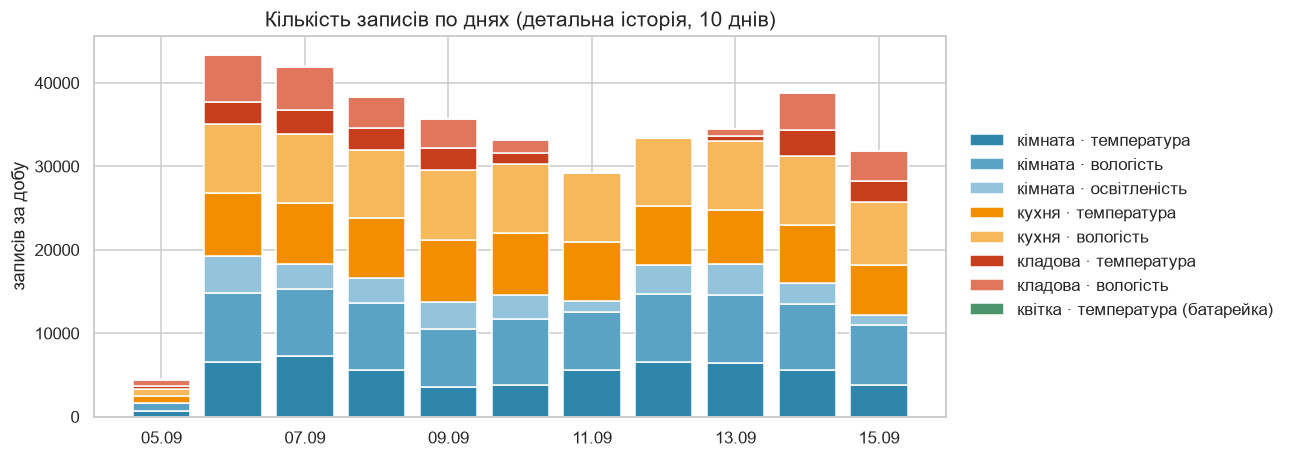

In [13]:
d = detailed.copy()
d["day"] = d.ts.dt.tz_convert(cleaning.KYIV).dt.normalize().dt.tz_localize(None)
piv = (d.pivot_table(index="day", columns="entity_id", values="value", aggfunc="size")
         .fillna(0))
piv = piv[[e for e in cleaning.LABELS_UA if e in piv.columns]]

fig, ax = plt.subplots(figsize=(10, 4.5))
bottom = np.zeros(len(piv))
for e in piv.columns:
    ax.bar(piv.index, piv[e].to_numpy(), bottom=bottom, width=0.8,
           label=cleaning.LABELS_UA[e], color=cleaning.ENTITY_COLORS[e], edgecolor="white")
    bottom += piv[e].to_numpy()
ax.set_title("Кількість записів по днях (детальна історія, 10 днів)")
ax.set_ylabel("записів за добу")
ax.set_xlabel("")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), frameon=False)
fig.savefig(IMAGES / "m1_records_per_day.png", dpi=150, bbox_inches="tight")
plt.show()

Повні доби дають 29–43 тис. записів; 05.09 і 15.09 нижчі, бо це неповні доби на краях вікна.
Провалів у зборі детальних даних за ці 10 днів не було.
Більшу частину об'єму дають кухня і житлова кімната — їхні датчики частіше змінюють значення.
Датчик квітки майже не видно: 723 записи проти 82 тис. у кухонної вологості — він на батарейці
й пише рідко, і саме тому переживає відключення світла.

### Покриття по датчиках

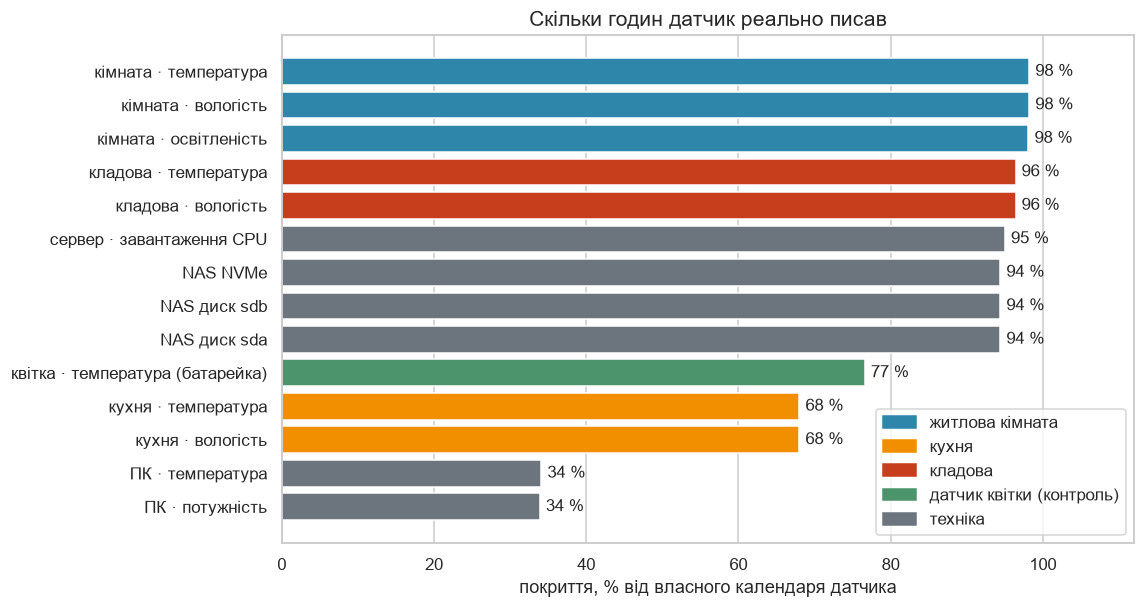

In [14]:
cov = report.sort_values("coverage_pct")
colors = [cleaning.ROOM_COLORS.get(r, "#6C757D") for r in cov.room]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(cov.label_ua, cov.coverage_pct, color=colors)
ax.bar_label(bars, fmt="%.0f %%", padding=4, fontsize=11)
ax.set_xlim(0, 112)
ax.set_xlabel("покриття, % від власного календаря датчика")
ax.set_title("Скільки годин датчик реально писав")
ax.grid(axis="y", visible=False)

handles = [plt.Rectangle((0, 0), 1, 1, color=c)
           for c in [cleaning.ROOM_COLORS[r] for r in ["Bedroom", "Kitchen", "Printernya",
                                                       "Soil", "Tech"]]]
labels = [cleaning.ROOM_LABELS_UA[r] for r in ["Bedroom", "Kitchen", "Printernya",
                                               "Soil", "Tech"]]
ax.legend(handles, labels, loc="lower right", frameon=True)
fig.savefig(IMAGES / "m1_coverage.png", dpi=150, bbox_inches="tight")
plt.show()

Житлова кімната і кладова майже ідеальні (98 % і 96 %), кухня провалилася до 68 % через
один місячний простій, а ПК на 34 % — це не дірка, а спосіб життя: комп'ютер часто вимкнений.

### Де саме є дані, а де їх немає (6 місяців)

Це найважливіша картинка модуля. Кольорова смуга — година з даними, світла — година без даних.
Саме на цьому полотні в модулі M2 з'являться блекаути: коли всі розеткові датчики
замовкають **одночасно**, а датчик квітки на батарейці продовжує писати — це відключення світла.

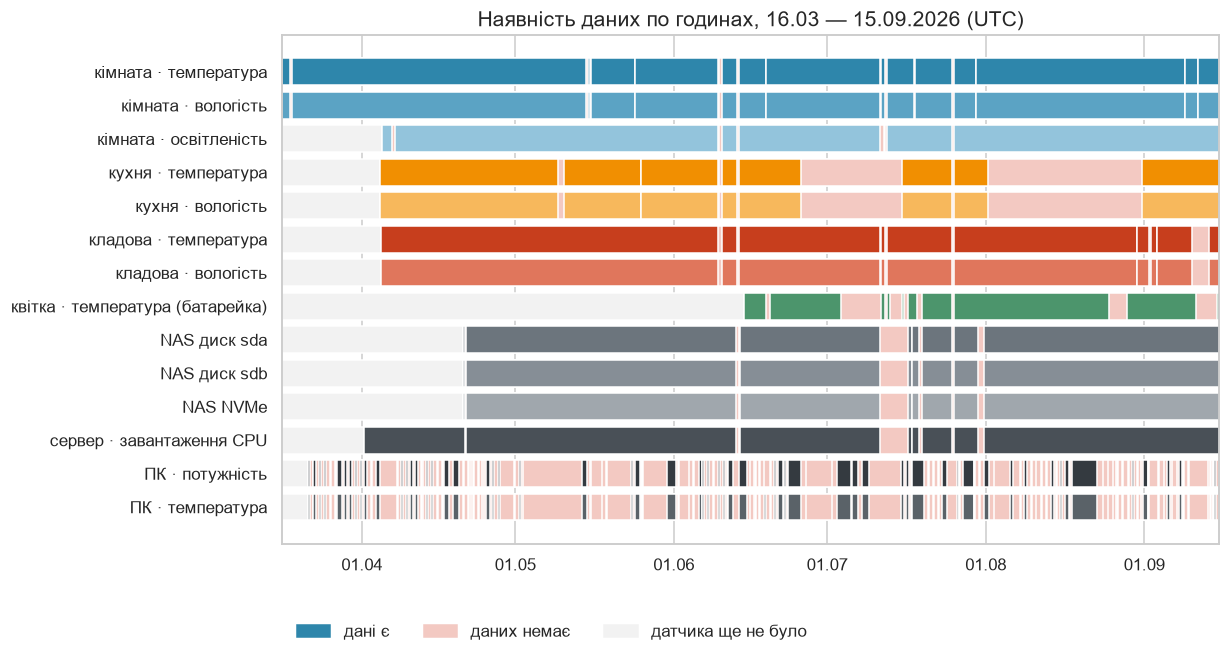

In [15]:
ents = [e for e in cleaning.LABELS_UA if e in set(hourly.entity_id)]
t0 = mdates.date2num(hourly.ts.min().tz_convert(None))
t1 = mdates.date2num(hourly.ts.max().tz_convert(None))

fig, ax = plt.subplots(figsize=(11, 6))
for i, e in enumerate(ents):
    g = hourly[hourly.entity_id == e].sort_values("ts")
    ts = g.ts.dt.tz_convert(None).to_numpy()
    ok = g["mean"].notna().to_numpy()
    s0 = mdates.date2num(ts[0])
    ax.broken_barh([(t0, t1 - t0)], (i - 0.4, 0.8), facecolors="#F2F2F2")   # датчика ще не було
    ax.broken_barh([(s0, t1 - s0)], (i - 0.4, 0.8), facecolors="#F3C9C2")   # немає даних
    edges = np.flatnonzero(np.diff(np.r_[False, ok, False]))
    segs = [(mdates.date2num(ts[a]), (b - a) / 24) for a, b in zip(edges[0::2], edges[1::2])]
    ax.broken_barh(segs, (i - 0.4, 0.8), facecolors=cleaning.ENTITY_COLORS[e])

ax.set_yticks(range(len(ents)))
ax.set_yticklabels([cleaning.LABELS_UA[e] for e in ents])
ax.invert_yaxis()
ax.set_xlim(t0, t1)
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d.%m"))
ax.set_title("Наявність даних по годинах, 16.03 — 15.09.2026 (UTC)")
ax.grid(axis="y", visible=False)

legend = [plt.Rectangle((0, 0), 1, 1, color="#2E86AB"),
          plt.Rectangle((0, 0), 1, 1, color="#F3C9C2"),
          plt.Rectangle((0, 0), 1, 1, color="#F2F2F2")]
ax.legend(legend, ["дані є", "даних немає", "датчика ще не було"],
          loc="lower left", bbox_to_anchor=(0, -0.22), ncol=3, frameon=False)
fig.savefig(IMAGES / "m1_gaps_timeline.png", dpi=150, bbox_inches="tight")
plt.show()

Три різні історії на одній картинці: суцільна смуга кухні в червні-липні — місячний простій
датчика; «гребінець» ПК — звичайний робочий графік людини; тонкі вертикальні щілини,
що проходять крізь **усі** розеткові датчики одразу — кандидати на відключення світла.

## Висновки

* **4 402 години × 14 датчиків** зведено в одну таблицю `hours_wide.csv`. Покриття кімнатних
  датчиків — **89 %**, по всіх датчиках — 81 %.
* **Класичного бруду майже немає**: 0 дублікатів, 0 викидів поза фізичним діапазоном,
  82 нечислові стани (0,02 %), з яких 70 — датчик квітки на батарейці.
* **Головна проблема — не бруд, а порожнеча**: 380 дірок > 1 год. Найбільша — 722 години
  (30 діб) на кухні; разом кухня втратила 1 263 години, тому її покриття лише 68 %.
* **Найнебезпечніша знахідка — «застряглий» датчик**: 6 періодів, 384 години, найдовший —
  144 години в житловій кімнаті (26,36 °C без жодної зміни 6 діб). Покриття там 98 %,
  але 3 % цих годин — фальшиві. Тому в чистих даних стоїть прапорець `stuck`.
* **Порожнеча ≠ помилка**: 34 % покриття ПК означає «ПК вимкнений», а не «дані втрачено».
  Це не дірка, яку треба латати, а сигнал, який треба читати (модуль M5).
* **Перехід на літній час нас не зачепив**, бо все зберігається в UTC; у київський час
  переводимо лише для підписів.

## Як сказати на співбесіді за 30 секунд

Я зібрала 4 402 години даних із 14 домашніх датчиків і перш за все перевірила їх на вісім типових
проблем: нечислові стани, дублікати, викиди, різна частота, часові пояси, літній час, дірки
й «застряглі» датчики. Виявилось, що очевидного бруду майже немає — 0 дублікатів і 0 викидів,
0,02 % нечислових станів. А от дві неочевидні речі вирішили все: датчик на кухні мовчав 30 діб
підряд, через що його покриття 68 %, і датчик у кімнаті шість діб поспіль видавав те саме
значення — покриття 98 %, але дані фальшиві. Тому я не просто рахую покриття, а веду окремий
прапорець «датчик застряг» і окрему таблицю дірок. І ще одне: у комп'ютера покриття 34 %,
але це не втрачені дані — це факт, що ПК вимкнений, і далі в проєкті він працює як сигнал.